In [15]:
import json

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math

from matplotlib.ticker import LogLocator, LogFormatterMathtext, NullFormatter
from src.data.data_spliting import load_data_split, get_scaler
from src.models.keras_models import ConcatenatedModulesModel

In [16]:
EXP_NAME = "multi_sat_ft_pierre"
EXP_CONFIG_PATH = f"../../experiments_config/{EXP_NAME}.json"

def class_instance_factory(model_name):
    if model_name == 'rf':
        return RandomForestModel()
    elif model_name == 'xgb':
        return XGBModel()
    elif model_name == 'cnn':
        return ConvolutionalModel()
    elif model_name == 'dnn':
        return DenseModel()
    elif model_name == 'bilstm':
        return BilstmModel()
    elif model_name in ['concatenatedCNN', "concatenatedDNN", "concatenatedBiLSTM"]:
        return ConcatenatedModulesModel(model_name)
    else:
        print(f"Class {model_name} not implemented")
        return None


In [17]:
# Load experiment configurations
with open(EXP_CONFIG_PATH, 'r') as f:
    exp_config = json.load(f)

EXP_FOLDER = f"../../{exp_config['EXP_NAME']}"
SPLITS = exp_config["N"]
SPLITS_PATH = f"../../{exp_config['SPLITS_PATH']}"
MODEL_NAMES = exp_config['MODEL_NAMES']
MODEL_NAME = "concatenatedCNN"


In [18]:
# Load data
x = pd.read_csv(f"../../{exp_config['INP_PATH']}", usecols=exp_config["INP_VARS"])[exp_config["INP_VARS"]]
y = pd.read_csv(f"../../{exp_config['OUT_PATH']}", usecols=exp_config["OUT_VARS"])[exp_config["OUT_VARS"]]

# y = y.loc[x["med and black sea"] == 1]
# x = x.loc[x["med and black sea"] == 1]
if exp_config["MEDITERRANEAN_ONLY"]:
    y = y.loc[x["med"]==1]
    x = x.loc[x["med"]==1]
print("Sample length: ", len(x))

y = y.rename(columns=dict(zip(exp_config["OUT_VARS"], exp_config["OUT_VARS_SHORT"])))
print(x.head())
print(y.head())

Sample length:  211
        412       442       490       560        673
0 -6.036779 -5.810679 -5.716559 -6.323540 -12.157430
1 -7.080496 -6.246448 -5.774595 -6.049910 -11.248573
2 -5.208365 -5.371085 -5.582091 -6.404230 -11.526055
3 -5.237646 -5.153856 -5.206167 -5.887345 -10.433162
4 -5.881441 -5.526887 -5.592439 -6.556424 -12.827311
     Chl c2      Peri  But-fuco      Fuco      Pras  Hex-fuco   Diadino  \
0 -3.759675 -5.220456 -4.025493 -3.471923 -5.141698 -2.926204 -4.127408   
1 -2.526734 -6.019557 -3.919411 -1.377048 -4.375505 -2.815168 -3.060349   
2 -3.027068 -5.664830 -3.275102 -2.770426 -4.263214 -2.047768 -3.334783   
3 -2.949139 -3.909288 -3.714424 -2.709167 -6.461596 -2.116768 -2.736279   
4 -3.213136 -4.119521 -3.241290 -2.841643 -5.233975 -2.135212 -2.698025   

       Allo       Zea  Chl b + DV Chl b    TChl a    bb-Car  
0 -4.653763 -2.317314         -3.284759 -0.901725 -4.155950  
1 -4.630406 -4.589091         -2.685720 -0.160461 -4.261988  
2 -3.467280 -3.938665    

In [19]:
all_y_true = []
all_y_pred = []
all_split_ids = []

for split in range(SPLITS):
    x_train, y_train, x_test, y_test = load_data_split(
        x, y, SPLITS_PATH, split, transform=False
    )

    PATH_MODELS = f'{EXP_FOLDER}/split_{split}/models'
    loaded_scaler = get_scaler(SPLITS_PATH, split)

    mod_ = ConcatenatedModulesModel(MODEL_NAME)
    mod_.load(PATH_MODELS)

    y_pred = pd.DataFrame(
        loaded_scaler.inverse_transform(mod_.predict(x_test)),
        columns=y_test.columns,
        index=y_test.index
    )

    # Store out-of-fold true values and predictions
    all_y_true.append(y_test.copy())
    all_y_pred.append(y_pred.copy())
    all_split_ids.extend([split] * len(y_test))


# Gather all out-of-fold predictions together
y_true_oof = pd.concat(all_y_true, axis=0)
y_pred_oof = pd.concat(all_y_pred, axis=0)

split_ids = np.array(all_split_ids)
        


In [20]:
all_y_true = []
all_y_pred = []
all_split_ids = []

for split in range(SPLITS):
    x_train, y_train, x_test, y_test = load_data_split(
        x, y, SPLITS_PATH, split, transform=False
    )

    PATH_MODELS = f'{EXP_FOLDER}/split_{split}/models'
    loaded_scaler = get_scaler(SPLITS_PATH, split)

    mod_ = ConcatenatedModulesModel(MODEL_NAME)
    mod_.load(PATH_MODELS)

    y_pred = pd.DataFrame(
        loaded_scaler.inverse_transform(mod_.predict(x_train)),
        columns=y_train.columns,
        index=y_train.index
    )

    # Store out-of-fold true values and predictions
    all_y_true.append(y_train.copy())
    all_y_pred.append(y_pred.copy())
    all_split_ids.extend([split] * len(y_train))


# Gather all out-of-fold predictions together
y_true_oof_train = pd.concat(all_y_true, axis=0)
y_pred_oof_train = pd.concat(all_y_pred, axis=0)

split_ids_grain = np.array(all_split_ids)

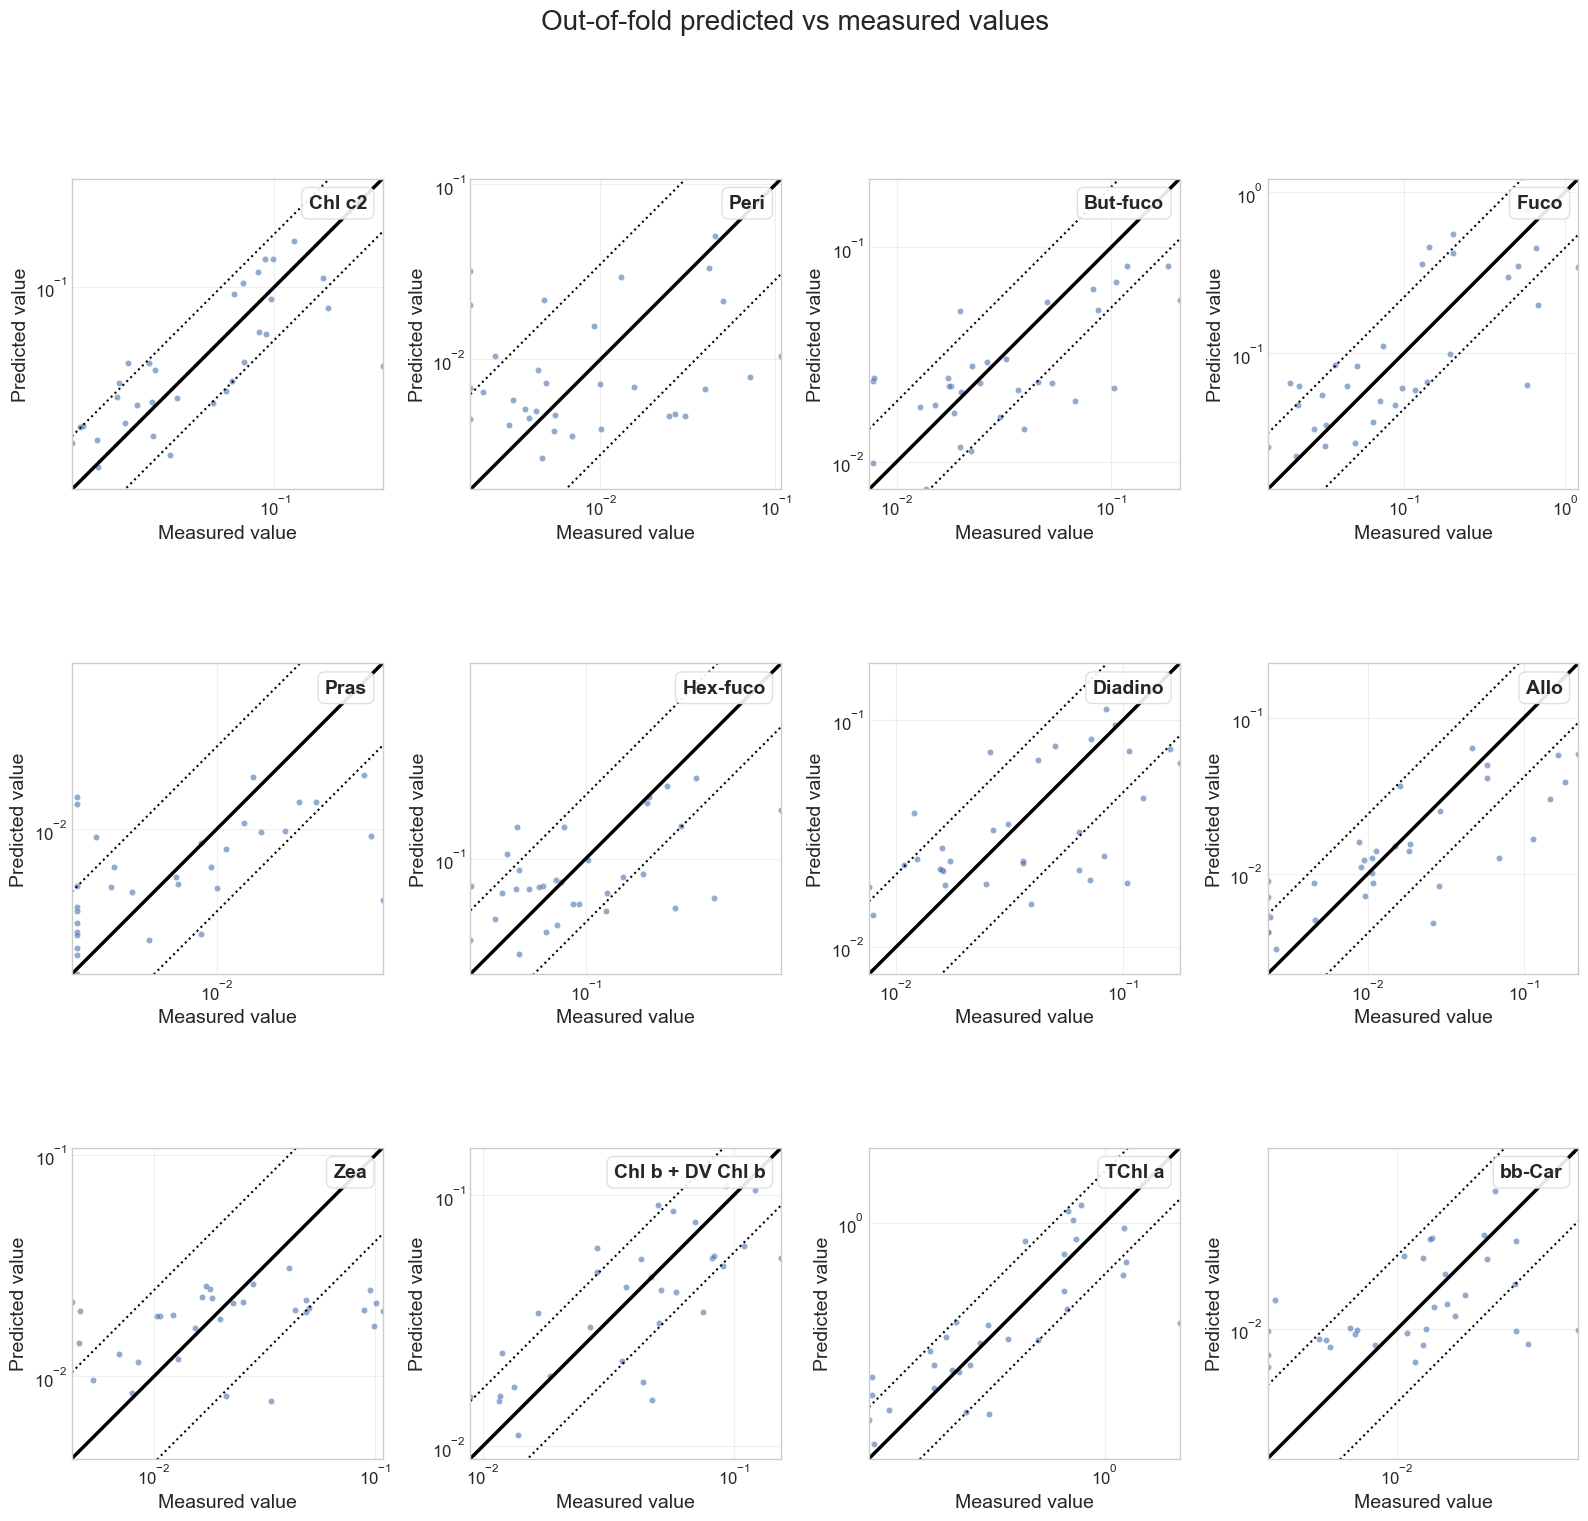

In [21]:
import math
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

n_outputs = len(y_true_oof.columns)

n_cols = 4
n_rows = math.ceil(n_outputs / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 16))
axes = axes.flatten()

for i, col in enumerate(y_true_oof.columns):
    ax = axes[i]

    measured = np.exp(y_true_oof[col].values)
    predicted = np.exp(y_pred_oof[col].values)

    # keep only valid positive values for log scale
    mask = np.isfinite(measured) & np.isfinite(predicted) & (measured > 0) & (predicted > 0)
    measured = measured[mask]
    predicted = predicted[mask]

    if len(measured) == 0:
        ax.axis("off")
        continue

    # scatter
    ax.scatter(
        measured,
        predicted,
        alpha=0.6,
        s=20,
        color="#4C72B0",
        edgecolors="white",
        linewidths=0.3
    )

    # common limits
    min_val = min(measured.min(), predicted.min())
    max_val = max(measured.max(), predicted.max())

    # 1:1 line
    x = np.logspace(np.log10(min_val), np.log10(max_val), 200)
    ax.plot(x, x, "k-", linewidth=2.5)

    # ±1 std lines in log space
    std = np.std(np.log10(predicted) - np.log10(measured))
    factor = 10 ** std
    ax.plot(x, x * factor, "k:", linewidth=1.5)
    ax.plot(x, x / factor, "k:", linewidth=1.5)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)

    # labels in every subplot
    ax.set_xlabel("Measured value", fontsize=14)
    ax.set_ylabel("Predicted value", fontsize=14)

    # tick size
    ax.tick_params(axis="both", labelsize=12)

    # pigment name inside the plot
    ax.text(
        0.95, 0.95, col,
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
        va="top",
        ha="right",
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="white",
            alpha=0.9,
            edgecolor="#dddddd"
        )
    )

    ax.grid(True, which="major", alpha=0.3)
    ax.set_aspect("equal", adjustable="box")

# remove empty panels
for j in range(n_outputs, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Out-of-fold predicted vs measured values", fontsize=20)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(f"{EXP_NAME}.png", dpi=300, bbox_inches="tight")
plt.show()

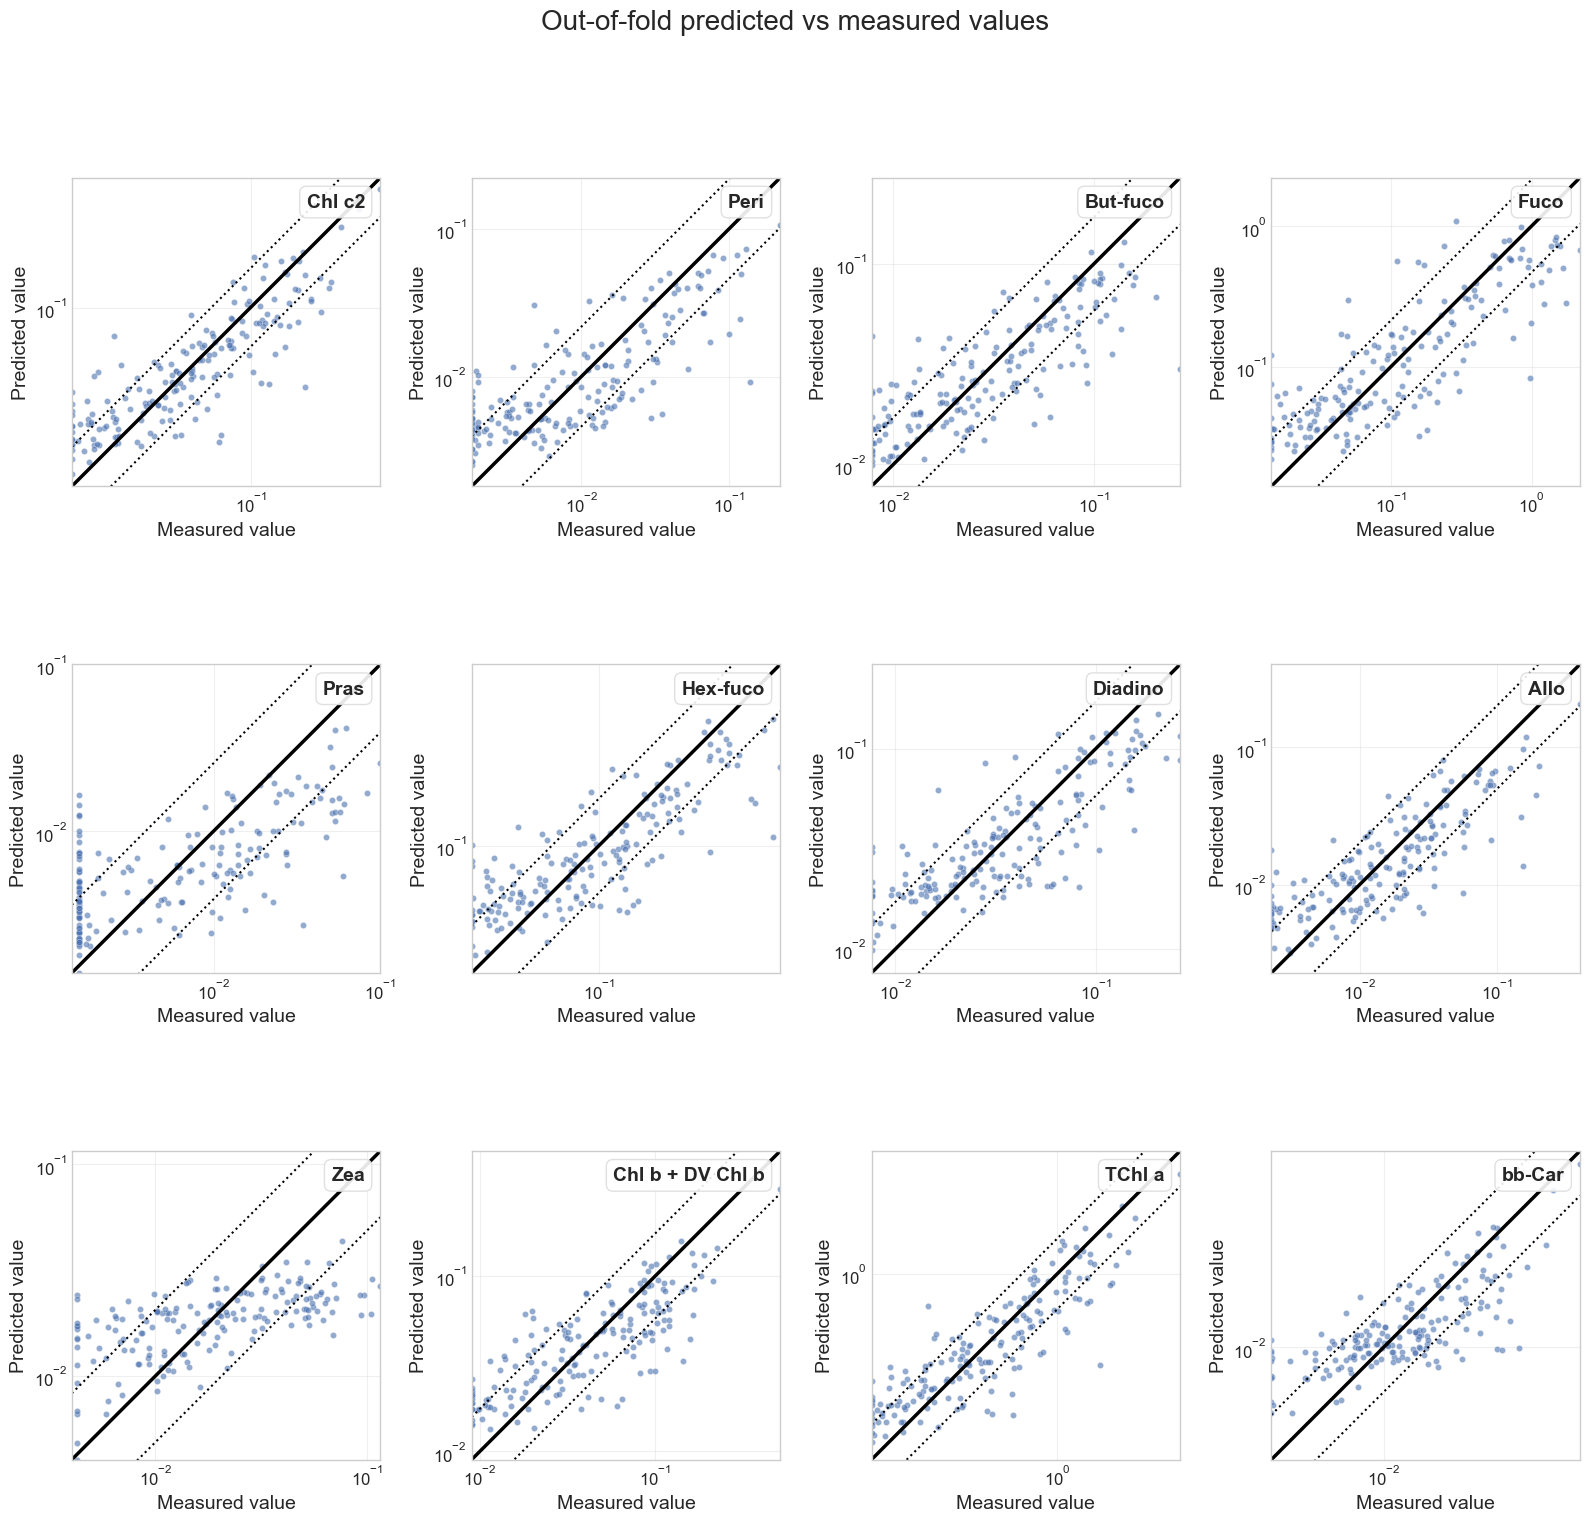

In [22]:
import math
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

n_outputs = len(y_true_oof.columns)

n_cols = 4
n_rows = math.ceil(n_outputs / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 16))
axes = axes.flatten()

for i, col in enumerate(y_true_oof.columns):
    ax = axes[i]

    measured = np.exp(y_true_oof_train[col].values)
    predicted = np.exp(y_pred_oof_train[col].values)

    # keep only valid positive values for log scale
    mask = np.isfinite(measured) & np.isfinite(predicted) & (measured > 0) & (predicted > 0)
    measured = measured[mask]
    predicted = predicted[mask]

    if len(measured) == 0:
        ax.axis("off")
        continue

    # scatter
    ax.scatter(
        measured,
        predicted,
        alpha=0.6,
        s=20,
        color="#4C72B0",
        edgecolors="white",
        linewidths=0.3
    )

    # common limits
    min_val = min(measured.min(), predicted.min())
    max_val = max(measured.max(), predicted.max())

    # 1:1 line
    x = np.logspace(np.log10(min_val), np.log10(max_val), 200)
    ax.plot(x, x, "k-", linewidth=2.5)

    # ±1 std lines in log space
    std = np.std(np.log10(predicted) - np.log10(measured))
    factor = 10 ** std
    ax.plot(x, x * factor, "k:", linewidth=1.5)
    ax.plot(x, x / factor, "k:", linewidth=1.5)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)

    # labels in every subplot
    ax.set_xlabel("Measured value", fontsize=14)
    ax.set_ylabel("Predicted value", fontsize=14)

    # tick size
    ax.tick_params(axis="both", labelsize=12)

    # pigment name inside the plot
    ax.text(
        0.95, 0.95, col,
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
        va="top",
        ha="right",
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="white",
            alpha=0.9,
            edgecolor="#dddddd"
        )
    )

    ax.grid(True, which="major", alpha=0.3)
    ax.set_aspect("equal", adjustable="box")

# remove empty panels
for j in range(n_outputs, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Out-of-fold predicted vs measured values", fontsize=20)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(f"{EXP_NAME}_train.png", dpi=300, bbox_inches="tight")
plt.show()

In [23]:
np.min(measured)

0.0036319787385061444

In [24]:
len(split_ids)

32

In [ ]:
len(split_ids)

In [ ]:
measured.min()

In [62]:
np.min([np.nan, 9])

nan

In [76]:
np.log10(np.e)

0.4342944819032518